# Loading libraries and Dataset

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
sns.set_theme(palette='SEt1',style='ticks' )

In [413]:
path= Path(r'Sales')

In [414]:
df_list= []
for file in path.glob('*.csv'):
    df= pd.read_csv(file)
    df_list.append(df)

df= pd.concat(df_list)

In [415]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [416]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186850 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 10.0+ MB


In [417]:
# Checking for null values
df.isnull().sum() / len(df) * 100

Order ID            0.291678
Product             0.291678
Quantity Ordered    0.291678
Price Each          0.291678
Order Date          0.291678
Purchase Address    0.291678
dtype: float64

In [418]:
# Dropping null values
df.dropna(inplace=True, axis=0)

In [419]:
# Checking for duplicates
df.duplicated().sum()

618

In [420]:
# Dropping duplicates
df.drop_duplicates(inplace=True)

In [421]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185687 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185687 non-null  object
 1   Product           185687 non-null  object
 2   Quantity Ordered  185687 non-null  object
 3   Price Each        185687 non-null  object
 4   Order Date        185687 non-null  object
 5   Purchase Address  185687 non-null  object
dtypes: object(6)
memory usage: 9.9+ MB


In [422]:

df=df[df['Order Date']!= 'Order Date']

In [423]:
#  Converting order date to the perfect format
df['Order Date']= pd.to_datetime(df['Order Date'],  format='mixed', dayfirst=True)

In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  object        
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  object        
 3   Price Each        185686 non-null  object        
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 9.9+ MB


In [425]:
# Setting order date as index
df.set_index('Order Date', inplace=True)

In [426]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-04-19 08:46:00,176558,USB-C Charging Cable,2,11.95,"917 1st St, Dallas, TX 75001"
2019-07-04 22:30:00,176559,Bose SoundSport Headphones,1,99.99,"682 Chestnut St, Boston, MA 02215"
2019-12-04 14:38:00,176560,Google Phone,1,600,"669 Spruce St, Los Angeles, CA 90001"
2019-12-04 14:38:00,176560,Wired Headphones,1,11.99,"669 Spruce St, Los Angeles, CA 90001"
2019-04-30 09:27:00,176561,Wired Headphones,1,11.99,"333 8th St, Los Angeles, CA 90001"


In [427]:
# Sorting data based on index
df.sort_index(inplace=True)

In [428]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001"
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016"
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150,"735 5th St, New York City, NY 10001"
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001"
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301"


In [429]:
df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Purchase Address    object
dtype: object

In [430]:
# fixing datatypes
df['Order ID']= df['Order ID'].astype('int64')
df['Price Each']= df['Price Each'].astype('float64')
df['Quantity Ordered']= df['Quantity Ordered'].astype('int64')

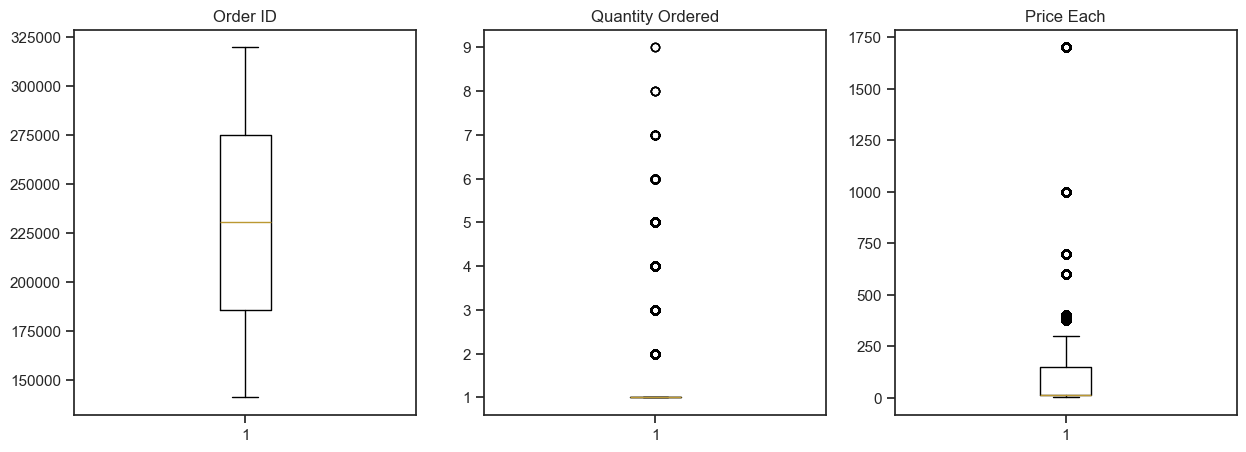

In [431]:
#  Visualizing distributions to find outliers

fig,axes= plt.subplots(1,3, figsize=(15,5))

axes= axes.reshape(-1)

for i,col in enumerate(df.select_dtypes(include=np.number)):
  axes[i].boxplot(df[col],
                  meanprops= {
                    "marker": "o",
                    "markerfacecolor": "White",
                    "markersize": "10"
                },)
  axes[i].set_title(col)
plt.show()

In [432]:
df[df['Quantity Ordered']==5].sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-05 23:48:00,201138,AAA Batteries (4-pack),5,2.99,"774 Elm St, Austin, TX 73301"
2019-12-03 13:43:00,171713,AAA Batteries (4-pack),5,2.99,"601 Park St, San Francisco, CA 94016"
2019-09-22 10:18:00,250432,AAA Batteries (4-pack),5,2.99,"634 Sunset St, New York City, NY 10001"
2019-02-13 10:45:00,160537,AA Batteries (4-pack),5,3.84,"766 Main St, Seattle, WA 98101"
2019-03-25 12:18:00,166976,AAA Batteries (4-pack),5,2.99,"333 7th St, Los Angeles, CA 90001"
2019-12-28 19:11:00,299444,AA Batteries (4-pack),5,3.84,"142 Ridge St, Los Angeles, CA 90001"
2019-06-19 12:34:00,219634,AAA Batteries (4-pack),5,2.99,"191 14th St, Los Angeles, CA 90001"
2019-12-06 19:41:00,214491,AAA Batteries (4-pack),5,2.99,"102 Dogwood St, Seattle, WA 98101"
2019-03-10 15:10:00,262072,AAA Batteries (4-pack),5,2.99,"796 South St, San Francisco, CA 94016"


In [433]:
df[df['Price Each']>= 250].sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-12-10 21:04:00,259524,34in Ultrawide Monitor,1,379.99,"384 Chestnut St, San Francisco, CA 94016"
2019-03-11 01:39:00,286437,34in Ultrawide Monitor,1,379.99,"724 1st St, Seattle, WA 98101"
2019-12-03 19:48:00,162533,iPhone,1,700.00,"361 Ridge St, San Francisco, CA 94016"
2019-08-10 07:56:00,274020,LG Washing Machine,1,600.00,"884 Jackson St, Seattle, WA 98101"
2019-02-19 17:57:00,152442,34in Ultrawide Monitor,1,379.99,"881 Pine St, Los Angeles, CA 90001"
2019-02-26 08:40:00,159877,27in 4K Gaming Monitor,1,389.99,"870 Chestnut St, New York City, NY 10001"
2019-07-10 10:20:00,266351,iPhone,1,700.00,"317 Ridge St, San Francisco, CA 94016"
2019-11-02 13:13:00,160650,iPhone,1,700.00,"337 14th St, San Francisco, CA 94016"
2019-01-28 09:06:00,145339,iPhone,1,700.00,"210 12th St, Seattle, WA 98101"


> Notice most of the items more than $250 are expensive items thus are not necessary outliesr same with the number of quantity ordered

In [434]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001"
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016"
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001"
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001"
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301"


In [435]:
df['Total_sales_price']= df['Quantity Ordered'] * df['Price Each']
df['purchase_city']= df['Purchase Address'].str.split(',').str.get(1)
df['postal_code']= df['Purchase Address'].str.slice(-5)
df['State']= df['Purchase Address'].str.slice(start=-8, stop=-6)

In [436]:
df['day']= df.index.day_name()
df['month']= df.index.month_name()
df['year']= df.index.year

In [437]:
df.sample(5)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Total_sales_price,purchase_city,postal_code,State,day,month,year
Order Date,,,,,,,,,,,,
2019-01-10 08:52:00,260968,AA Batteries (4-pack),2,3.84,"381 Lakeview St, Seattle, WA 98101",7.68,Seattle,98101,WA,Thursday,January,2019
2019-12-17 07:58:00,316934,27in 4K Gaming Monitor,1,389.99,"517 Main St, Seattle, WA 98101",389.99,Seattle,98101,WA,Tuesday,December,2019
2019-11-05 13:17:00,201267,USB-C Charging Cable,3,11.95,"47 8th St, San Francisco, CA 94016",35.85,San Francisco,94016,CA,Tuesday,November,2019
2019-06-05 23:23:00,199479,Lightning Charging Cable,1,14.95,"546 1st St, New York City, NY 10001",14.95,New York City,10001,NY,Wednesday,June,2019
2019-08-28 20:58:00,243305,Vareebadd Phone,1,400.00,"401 Chestnut St, San Francisco, CA 94016",400.00,San Francisco,94016,CA,Wednesday,August,2019


# Eda and Visualizations

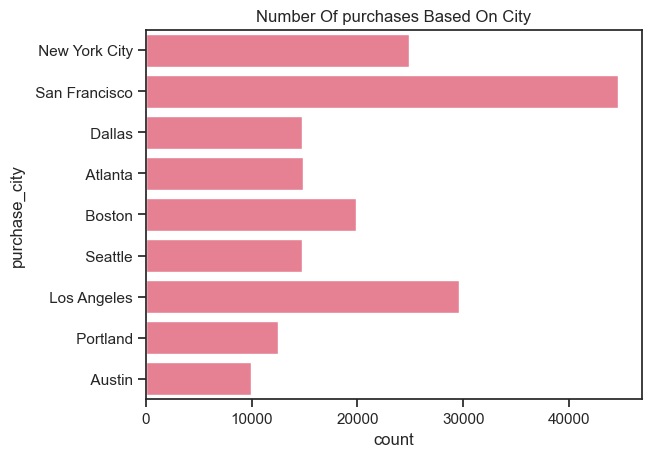

In [438]:
plt.Figure(figsize=(6.4, 4.6))

sns.countplot(data=df, y= 'purchase_city')
plt.title('Number Of purchases Based On City')

plt.show()

In [ ]:
plt.figure(figsize=(10,6))


sns.boxplot(data=df,y='Total_sales_price', x='purchase_city', showmeans= True,
            meanprops= {
                    "marker": "o",
                    "markerfacecolor": "White",
                    "markersize": "10"
                }, )



plt.title('Amount spent Based On City')
plt.show()